# Interpreting sequence features of *in vivo* enzymes

This notebook runs the InterPLM pipeline to extract sequence embeddings from ESM2, and do an interpretability analysis on these. 

The sequences correspond to in vivo enzymes not appearing on in vitro datasets (CatPredDB, recovering enzymes from BRENDA and Sabio-RK). 

In [4]:
# automatic module reloading
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add paths & directories for imports
sys.path.append(str(Path("..").resolve()))
sys.path.append(str((Path("..") / "interplm").resolve()))

# Data directory
data_dir = Path("..") / "data"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Get pLM embeddings for training data

### 1.1. Download sequences from UniProt

In [ ]:
# Read CSV with sequences
seqs_file = data_dir / "in_vivo_enzymes" / "kmax_not_in_catpred.csv"
df = pd.read_csv(seqs_file)

# Write to FASTA format
output_file = data_dir / "in_vivo_enzymes" / "kmax_not_in_catpred.fasta"

with open(output_file, 'w') as f:
    for idx, row in df.iterrows():
        # Create a simple header with index
        f.write(f'>seq_{idx}\n')
        # Write the sequence
        f.write(f'{row["sequence"]}\n')

print(f"Converted {len(df)} sequences to FASTA format")

Converted 197 sequences to FASTA format


In [5]:
from interplm.data_processing.shard_fasta import shard_fasta

# Paths
input_fasta = Path(data_dir) / 'in_vivo_enzymes' / 'kmax_not_in_catpred.fasta'
output_shards_dir = Path(data_dir) / 'in_vivo_enzymes_shards'

# Shard the FASTA file (with 197 sequences)
num_shards = shard_fasta(
    input_file=input_fasta,
    output_dir=output_shards_dir,
    proteins_per_shard=50  # This will create ~4 shards
)

print(f"Created {num_shards} shards in {output_shards_dir}")

Proteins per shard: 50
System file limit: 1024
Using max_open_files: 924
Counting total proteins...


394it [00:00, 473919.06it/s]


Total proteins: 197
Number of shards: 4
Sharding proteins...


100%|██████████| 197/197 [00:00<00:00, 28844.44 proteins/s]

Created 4 shards in ../data/in_vivo_enzymes_shards


### 1.2. Get ESM-2 Embeddings

In [ ]:
from interplm.esm.fasta_to_sae_dataset import process_shard_range

# Define paths
fasta_shards_dir = Path(data_dir) / 'in_vivo_enzymes_shards'
embeddings_output_dir = Path(data_dir) / 'in_vivo_enzymes_embds'

# Process all shards and extract embeddings from layer 4
process_shard_range(
    fasta_dir=fasta_shards_dir,
    output_dir=embeddings_output_dir,
    esm_model_name="esm2_t6_8M_UR50D",  
    layers=[4],
    start_shard=None,
    end_shard=None,
    corrupt_esm=False
)

print(f"Embeddings saved to {embeddings_output_dir}")

/nfs/homes/chinasse/miniconda3/envs/interplm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /nfs/homes/chinasse/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /nfs/homes/chinasse/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


Read ../data/in_vivo_enzymes_shards/shard_0.fasta with 49 sequences


Processing batches: 100%|██████████| 28/28 [00:01<00:00, 14.60it/s]


Saved activations for layer 4, shard 0 to ../data/in_vivo_enzymes_embds/layer_4/shard_0/activations.pt
Read ../data/in_vivo_enzymes_shards/shard_1.fasta with 50 sequences


Processing batches: 100%|██████████| 25/25 [00:00<00:00, 71.31it/s]


Saved activations for layer 4, shard 1 to ../data/in_vivo_enzymes_embds/layer_4/shard_1/activations.pt
Read ../data/in_vivo_enzymes_shards/shard_2.fasta with 50 sequences


Processing batches: 100%|██████████| 22/22 [00:00<00:00, 60.84it/s]


Saved activations for layer 4, shard 2 to ../data/in_vivo_enzymes_embds/layer_4/shard_2/activations.pt
Read ../data/in_vivo_enzymes_shards/shard_3.fasta with 48 sequences


Processing batches: 100%|██████████| 17/17 [00:00<00:00, 58.05it/s]


Saved activations for layer 4, shard 3 to ../data/in_vivo_enzymes_embds/layer_4/shard_3/activations.pt
Embeddings saved to ../data/in_vivo_enzymes_embds


## 2. Train sparse autoencoders

In [14]:
from interplm.train.train_plm_sae import train_SAE_on_PLM_embeds

# Define paths
layer = 4
plm_embd_dir = Path(data_dir) / 'in_vivo_enzymes_embds' / f'layer_{layer}'
save_dir = Path('..') / 'models' / 'in_vivo_sae_model'

# Train the SAE with GPU logging
train_SAE_on_PLM_embeds(
    plm_embd_dir=plm_embd_dir,
    save_dir=str(save_dir),
    expansion_factor=8,  # Dictionary will be 8x the embedding dimension
    batch_size=32,
    steps=1000,  # Adjust based on your needs
    lr=1e-3,
    l1_penalty=1e-1,
    log_steps=100,
    save_steps=50,
    use_wandb=False 
)

Loading dataset metadata


100%|██████████| 4/4 [00:00<00:00, 1503.33it/s]


Using activations from layer 4 of esm2_t6_8M_UR50D
Loaded dataset with 72,906 tokens
Training with config: {'dict_class': 'AutoEncoder', 'trainer_class': 'StandardTrainer', 'activation_dim': 320, 'dict_size': 2560, 'lr': 0.001, 'l1_penalty': 0.1, 'l1_annealing_steps': 50, 'steps': 1000, 'warmup_steps': 50, 'resample_steps': None, 'device': 'cuda', 'layer': 4, 'plm_name': 'esm2_t6_8M_UR50D', 'wandb_name': 'SAE', 'submodule_name': None}


100%|██████████| 1000/1000 [00:03<00:00, 260.29it/s]

Stopped training because reached max specified steps


## 3. Analyze associations between feature activations and UniProtKB annotations

### 3.1. Download and Extract UniProtKB Annotations

 Download Swiss-Prot subset for concept evaluation. It corresponds to annotations for proteins from mice with 3D structures, high quality annotations, and < 400 amino acids/protein, which leaves us with 800 sequences and a ~200kb download. 
 
TO DO: to include more data, remove `+AND+%28proteins_with%3A1%29+AND+%28annotation_score%3A5%29+AND+%28model_organism%3A10090%29+AND+%28length%3A%5B1+TO+400%5D%29` from the end of the query. 

In [15]:
import subprocess
import urllib.request

# Create directory
concept_data_dir = data_dir / "uniprotkb"
concept_data_dir.mkdir(parents=True, exist_ok=True)

# Download Swiss-Prot subset
url = "https://rest.uniprot.org/uniprotkb/stream?compressed=true&fields=accession%2Creviewed%2Cprotein_name%2Clength%2Csequence%2Cec%2Cft_act_site%2Cft_binding%2Ccc_cofactor%2Cft_disulfid%2Cft_carbohyd%2Cft_lipid%2Cft_mod_res%2Cft_signal%2Cft_transit%2Cft_helix%2Cft_turn%2Cft_strand%2Cft_coiled%2Ccc_domain%2Cft_compbias%2Cft_domain%2Cft_motif%2Cft_region%2Cft_zn_fing%2Cxref_alphafolddb&format=tsv&query=%28reviewed%3Atrue%29+AND+%28proteins_with%3A1%29+AND+%28annotation_score%3A5%29+AND+%28model_organism%3A10090%29+AND+%28length%3A%5B1+TO+400%5D%29"
proteins_file = concept_data_dir / "proteins.tsv.gz"
urllib.request.urlretrieve(url, proteins_file)

print(f"Downloaded UniProtKB data to {proteins_file}")

Downloaded UniProtKB data to ../data/uniprotkb/proteins.tsv.gz


### 3.2. Extract Binary Concept Labels

In [16]:
from interplm.concept.extract_uniprotkb_annotations import main as extract_annotations

# Extract annotations and shard the data
annotations_dir = concept_data_dir / "annotations"

extract_annotations(
    input_uniprot_path=proteins_file,
    output_dir=annotations_dir,
    n_shards=4,
    min_required_instances=10,
    overwrite=False
)

print(f"Annotations extracted to {annotations_dir}")

2025-10-02 19:42:22,516 - INFO - Starting UniProt data processing...
2025-10-02 19:42:23,404 - INFO - Processing shard 2...
2025-10-02 19:42:23,404 - INFO - Processing shard 0...
2025-10-02 19:42:23,404 - INFO - Processing shard 1...
2025-10-02 19:42:23,405 - INFO - Processing shard 3...
2025-10-02 19:42:23,584 - INFO - Processing categorical column: Active site
2025-10-02 19:42:23,595 - INFO - Processing categorical column: Active site
2025-10-02 19:42:23,598 - INFO - Processing categorical column: Binding site
2025-10-02 19:42:23,609 - INFO - Processing categorical column: Binding site
2025-10-02 19:42:23,613 - INFO - Processing categorical column: Active site
2025-10-02 19:42:23,624 - INFO - Processing categorical column: Active site
2025-10-02 19:42:23,627 - INFO - Processing categorical column: Binding site
2025-10-02 19:42:23,637 - INFO - Processing categorical column: Cofactor
2025-10-02 19:42:23,640 - INFO - Processing categorical column: Binding site
2025-10-02 19:42:23,641 - 

Annotations extracted to ../data/uniprotkb/annotations


### 3.3. Convert Protein Sequences to ESM Embeddings

In [17]:
from interplm.esm.embed_uniprotkb import embed_all_shards

# Embed the UniProtKB proteins using the same layer
layer = 4
embeddings_dir = concept_data_dir / "embeddings"

embed_all_shards(
    input_dir=annotations_dir,
    output_dir=embeddings_dir,
    layer=layer,
    esm_name="esm2_t6_8M_UR50D"
)

print(f"Embeddings saved to {embeddings_dir}")

Embedding 210 proteins from Uniprot database using esm2_t6_8M_UR50D...
Processing 210 sequences


Processing batches: 100%|██████████| 14/14 [00:00<00:00, 32.65it/s]


Processed 54,137 tokens in total
Embedding computation complete. Saved to ../data/uniprotkb/embeddings/shard_3.pt
Embedding 212 proteins from Uniprot database using esm2_t6_8M_UR50D...
Processing 212 sequences


Processing batches: 100%|██████████| 14/14 [00:00<00:00, 31.92it/s]


Processed 55,154 tokens in total
Embedding computation complete. Saved to ../data/uniprotkb/embeddings/shard_0.pt
Embedding 212 proteins from Uniprot database using esm2_t6_8M_UR50D...
Processing 212 sequences


Processing batches: 100%|██████████| 14/14 [00:00<00:00, 30.85it/s]


Processed 54,794 tokens in total
Embedding computation complete. Saved to ../data/uniprotkb/embeddings/shard_2.pt
Embedding 212 proteins from Uniprot database using esm2_t6_8M_UR50D...
Processing 212 sequences


Processing batches: 100%|██████████| 15/15 [00:00<00:00, 42.07it/s]


Processed 58,179 tokens in total
Embedding computation complete. Saved to ../data/uniprotkb/embeddings/shard_1.pt
Embeddings saved to ../data/uniprotkb/embeddings


### 3.4. Normalize the SAE

In [18]:
from interplm.sae.normalize import normalize_sae_features

# Normalize SAE based on max activating examples
sae_dir = Path('..') / 'models' / 'in_vivo_sae_model'

# Determine number of embedding shards
n_embedding_shards = 4

normalize_sae_features(
    sae_dir=sae_dir,
    esm_embds_dir=embeddings_dir,
    n_shards=n_embedding_shards
)

print(f"Normalized SAE saved to {sae_dir / 'ae_normalized.pt'}")

Loading SAE model and calculating feature statistics...
Creating normalized SAE model...
Normalized model saved to ../models/in_vivo_sae_model/ae_normalized.pt
Normalized SAE saved to ../models/in_vivo_sae_model/ae_normalized.pt


### 3.5. Prepare Evaluation Sets

In [19]:
from interplm.concept.prepare_concept_eval_set import make_eval_subset

# Split shards into validation and test sets
total_shards = 4
valid_shards = list(range(0, total_shards // 2))  # First half for validation
test_shards = list(range(total_shards // 2, total_shards))  # Second half for test

make_eval_subset(
    valid_shards=valid_shards,
    test_shards=test_shards,
    uniprot_dir=annotations_dir,
    min_aa_per_concept=500,  # Lower threshold for small dataset
    min_domains_per_concept=5
)

print("Evaluation sets created")

Filtered from 134 concepts to 83 concepts with at least 500 amino acids or 5 domains
Concept evaluation subset created in ../data/uniprotkb/annotations/valid
Concept evaluation subset created in ../data/uniprotkb/annotations/test
Evaluation sets created


### 3.6. Compare Features to Concepts

In [24]:
from interplm.concept.compare_activations_to_concepts import analyze_all_shards_in_set
from interplm.concept.calculate_f1 import combine_metrics_across_shards as calculate_f1_scores

# Results directory
results_dir = Path('..') / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

# Process both validation and test sets
for eval_set in ['valid', 'test']:
    print(f"\nProcessing {eval_set} set...")
    
    # Compare activations to concepts
    eval_output_dir = results_dir / f'{eval_set}_counts'
    
    analyze_all_shards_in_set(
        sae_dir=sae_dir,
        esm_embds_dir=embeddings_dir,
        eval_set_dir=annotations_dir / eval_set,
        output_dir=eval_output_dir,
        is_sparse=True
    )
    
    # Calculate F1 scores
    calculate_f1_scores(
        eval_res_dir=eval_output_dir,
        eval_set_dir=annotations_dir / eval_set
    )
    
    print(f"F1 scores saved to {eval_output_dir / 'concept_f1_scores.csv'}")


Processing valid set...
Analyzing set valid with [0, 1] shards
Calculating over 2560 features in 11 chunks


100%|██████████| 11/11 [00:38<00:00,  3.54s/it]


Calculating over 2560 features in 11 chunks


Combining shard counts: 100%|██████████| 2/2 [00:00<00:00,  9.64it/s]


Calculating F1 scores...
Metrics saved to ../results/valid_counts/concept_f1_scores.csv
F1 scores saved to ../results/valid_counts/concept_f1_scores.csv

Processing test set...
Analyzing set test with [2, 3] shards
Calculating over 2560 features in 11 chunks


100%|██████████| 11/11 [00:38<00:00,  3.52s/it]


Calculating over 2560 features in 11 chunks


Combining shard counts: 100%|██████████| 2/2 [00:00<00:00,  9.03it/s]


Calculating F1 scores...
Metrics saved to ../results/test_counts/concept_f1_scores.csv
F1 scores saved to ../results/test_counts/concept_f1_scores.csv


## 3.7 Reporting final metrics

In [26]:
from interplm.concept.report_final_metrics import report_metrics

# Report metrics on test set based on pairs selected in validation set
report_metrics(
    valid_path=results_dir / 'valid_counts' / 'concept_f1_scores.csv',
    test_path=results_dir / 'test_counts' / 'concept_f1_scores.csv'
)

print("\nAnalysis complete")

Compared 2,559 features (with 1+ true positive) to 63 concepts (that are not amino acids)
Saved best pairings per concept to ../results/test_counts/heldout_top_pairings.csv and all top pairings to ../results/test_counts/heldout_all_top_pairings.csv
--------------------------------------------------
Average best F1 per concept in test set: 0.207
Number of concepts identified: 6
Number of features associated with a concept: 383

Analysis complete


## 3.8 Visualization (manual)


Top 10 feature-concept associations (validation set):


,feature,concept,f1_per_domain,precision,recall_per_domain,threshold_pct
58613,119,Domain_C-type lectin,1.0,1.0,1.0,0.6
58617,120,Domain_C-type lectin,1.0,1.0,1.0,0.5
58618,120,Domain_C-type lectin,1.0,1.0,1.0,0.6
59284,475,Domain_C-type lectin,1.0,1.0,1.0,0.5
59285,475,Domain_C-type lectin,1.0,1.0,1.0,0.6
59335,505,Domain_C-type lectin,1.0,1.0,1.0,0.5
59336,505,Domain_C-type lectin,1.0,1.0,1.0,0.6
59528,598,Domain_C-type lectin,1.0,1.0,1.0,0.5
59806,747,Domain_C-type lectin,1.0,1.0,1.0,0.5
59807,747,Domain_C-type lectin,1.0,1.0,1.0,0.6



Top 10 feature-concept associations (test set):


,feature,concept,f1_per_domain,precision,recall_per_domain,threshold_pct
58181,99,Domain_C-type lectin,1.0,1.0,1.0,0.8
58223,120,Domain_C-type lectin,1.0,1.0,1.0,0.5
58224,120,Domain_C-type lectin,1.0,1.0,1.0,0.6
58280,147,Domain_C-type lectin,1.0,1.0,1.0,0.6
58919,475,Domain_C-type lectin,1.0,1.0,1.0,0.8
59167,598,Domain_C-type lectin,1.0,1.0,1.0,0.5
59168,598,Domain_C-type lectin,1.0,1.0,1.0,0.6
59224,625,Domain_C-type lectin,1.0,1.0,1.0,0.6
59337,691,Domain_C-type lectin,1.0,1.0,1.0,0.8
59450,747,Domain_C-type lectin,1.0,1.0,1.0,0.5


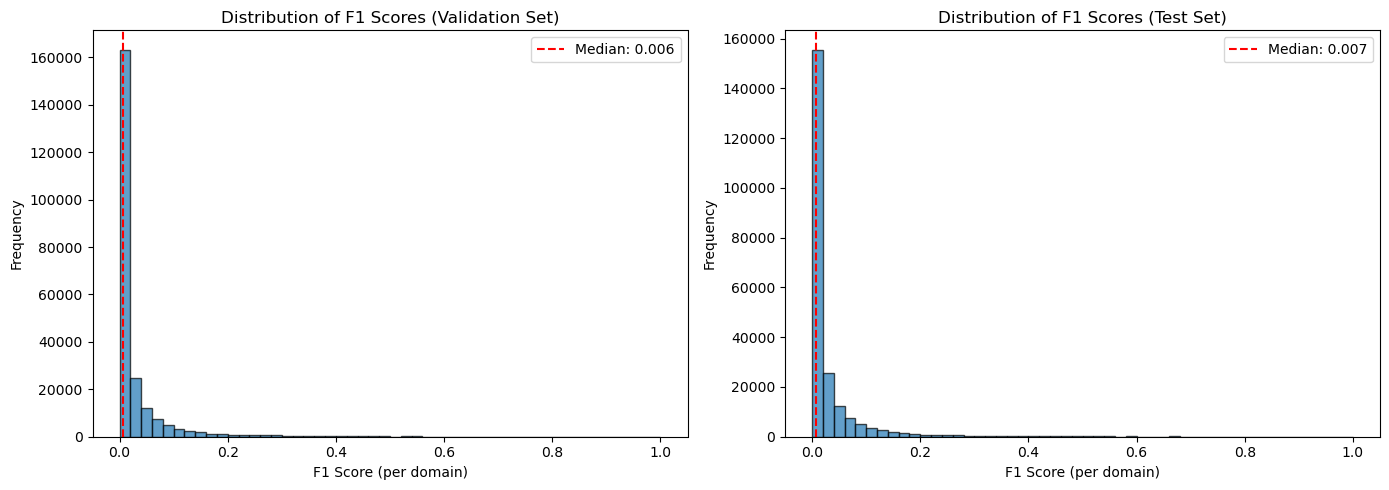


Plot saved to ../results/f1_distributions.png


In [27]:
# Read the final results
valid_results = pd.read_csv(results_dir / 'valid_counts' / 'concept_f1_scores.csv')
test_results = pd.read_csv(results_dir / 'test_counts' / 'concept_f1_scores.csv')

# Display top associations
print("\nTop 10 feature-concept associations (validation set):")
top_valid = valid_results.nlargest(10, 'f1_per_domain')[['feature', 'concept', 'f1_per_domain', 'precision', 'recall_per_domain', 'threshold_pct']]
display(top_valid)

print("\nTop 10 feature-concept associations (test set):")
top_test = test_results.nlargest(10, 'f1_per_domain')[['feature', 'concept', 'f1_per_domain', 'precision', 'recall_per_domain', 'threshold_pct']]
display(top_test)

# Plot distribution of F1 scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation set
axes[0].hist(valid_results['f1_per_domain'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('F1 Score (per domain)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of F1 Scores (Validation Set)')
axes[0].axvline(valid_results['f1_per_domain'].median(), color='red', linestyle='--', label=f'Median: {valid_results["f1_per_domain"].median():.3f}')
axes[0].legend()

# Test set
axes[1].hist(test_results['f1_per_domain'], bins=50, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('F1 Score (per domain)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of F1 Scores (Test Set)')
axes[1].axvline(test_results['f1_per_domain'].median(), color='red', linestyle='--', label=f'Median: {test_results["f1_per_domain"].median():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(results_dir / 'f1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to {results_dir / 'f1_distributions.png'}")

## 4. Dashboard 

#### 4.1. Ensure Report Metrics Has Created Dashboard Files

In [28]:
from interplm.concept.report_final_metrics import report_metrics

# Make sure the heldout_all_top_pairings.csv file exists (required for dashboard)
results_dir = Path('..') / 'results'

# This creates both heldout_top_pairings.csv and heldout_all_top_pairings.csv
report_metrics(
    valid_path=results_dir / 'valid_counts' / 'concept_f1_scores.csv',
    test_path=results_dir / 'test_counts' / 'concept_f1_scores.csv',
    top_threshold=0.5  # Adjust this to set minimum F1 score for feature-concept pairs
)

# Verify the file was created
dashboard_concept_file = results_dir / 'test_counts' / 'heldout_all_top_pairings.csv'
if dashboard_concept_file.exists():
    print(f"Dashboard concept file created: {dashboard_concept_file}")
    # Preview the top results
    top_pairs = pd.read_csv(dashboard_concept_file)
    print(f"\nFound {len(top_pairs)} feature-concept pairs with F1 > 0.5")
    print(f"\nTop 5 feature-concept associations:")
    print(top_pairs.head()[['feature', 'concept', 'f1_per_domain', 'precision', 'recall_per_domain']])
else:
    print(f"Warning: Dashboard concept file not created")

Compared 2,559 features (with 1+ true positive) to 63 concepts (that are not amino acids)
Saved best pairings per concept to ../results/test_counts/heldout_top_pairings.csv and all top pairings to ../results/test_counts/heldout_all_top_pairings.csv
--------------------------------------------------
Average best F1 per concept in test set: 0.207
Number of concepts identified: 6
Number of features associated with a concept: 383
Dashboard concept file created: ../results/test_counts/heldout_all_top_pairings.csv

Found 435 feature-concept pairs with F1 > 0.5

Top 5 feature-concept associations:
   feature               concept  f1_per_domain  precision  recall_per_domain
0     1744  Domain_C-type lectin            1.0        1.0                1.0
1      799  Domain_C-type lectin            1.0        1.0                1.0
2     1674  Domain_C-type lectin            1.0        1.0                1.0
3     2207  Domain_C-type lectin            1.0        1.0                1.0
4      598  

## 4.2. Create dashboard cache

In [36]:
# Set environment variable BEFORE importing interplm modules
dashboard_cache_dir = Path('..') / 'data' / 'dashboard_cache'
dashboard_cache_dir.mkdir(parents=True, exist_ok=True)
dashboard_cache_path = dashboard_cache_dir / 'in_vivo_dashboard_cache.pkl'
os.environ['DASHBOARD_CACHE'] = str(dashboard_cache_path.resolve())

from interplm.feature_vis.start_dashboard_cache import add_layer_to_dashboard

# Set up paths
layer = 4
sae_dir = Path('..') / 'models' / 'in_vivo_sae_model'
sae_normalized_path = sae_dir / 'ae_normalized.pt'
embeddings_dir = Path('..') / 'data' / 'uniprotkb' / 'embeddings'
aa_metadata_dir = Path('..') / 'data' / 'uniprotkb' / 'annotations'
concept_results_dir = results_dir / 'test_counts'

# number of shards
n_shards = 4

# Set dashboard cache location
dashboard_cache_dir = Path('..') / 'data' / 'dashboard_cache'
dashboard_cache_dir.mkdir(parents=True, exist_ok=True)
os.environ['DASHBOARD_CACHE'] = str(dashboard_cache_dir / 'in_vivo_dashboard_cache.pkl')

# Create the dashboard cache
add_layer_to_dashboard(
    sae_path=sae_normalized_path,
    esm_embeds_dir=embeddings_dir,
    aa_metadata_dir=aa_metadata_dir,
    n_shards=n_shards,
    esm_model_name="esm2_t6_8M_UR50D",
    layer=layer,
    concept_dir=concept_results_dir
)

print(f"\nDashboard cache created at: {os.environ['DASHBOARD_CACHE']}")


Finding max in feature chunks, uniprot shard 3: 100%|██████████| 1/1 [00:03<00:00,  3.14s/it]


Adding layer 4 to dashboard cache at /nfs/homes/chinasse/InterPLM/data/dashboard_cache/dashboard_cache_650M.pkl
Saving final results to dashboard cache at /nfs/homes/chinasse/InterPLM/data/dashboard_cache/dashboard_cache_650M.pkl

Dashboard cache created at: ../data/dashboard_cache/in_vivo_dashboard_cache.pkl


## 4.3. Verifying dashboard set up

In [ ]:
# Reset dashboard cache location
os.environ['DASHBOARD_CACHE'] = str(Path('..').resolve() / 'data' / 'dashboard_cache' / 'dashboard_cache_650M.pkl')
print(f"Dashboard cache set to: {os.environ['DASHBOARD_CACHE']}")

# Check if it exists
if dashboard_cache.exists():
    import pickle
    with open(dashboard_cache, 'rb') as f:
        cache = pickle.load(f)
    
    print(f"\nDashboard cache contains layers: {list(cache.keys())}")


Dashboard cache set to: /nfs/homes/chinasse/InterPLM/data/dashboard_cache/dashboard_cache_650M.pkl

Dashboard cache contains layers: [4]


TO DO: Finish dashboard creation